# Comparative Analysis: Multi-Model Performance Across Datasets and Training Fractions

## Purpose

This notebook compares multiple sequence models to identify regimes where each model excels:

- **Sequence length**: Short vs long sequences
- **Dataset size**: Full dataset vs limited training fractions
- **Training fraction**: Performance across different data availability levels
- **Task type**: Classification, regression, forecasting

We use **task-specific primary metrics** (accuracy, F1, MAE) and analyze **relative performance** between all models.

**Models**: Configured in `MODELS` variable (currently: LMU, S4, Mamba)


In [1]:
from pathlib import Path
from typing import Dict, Any
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

current_dir = Path.cwd()
RESULTS_ROOT = current_dir.parent

MODELS = ["lmu", "s4", "mamba"]
FRACTIONS = [0.1, 0.25, 0.5, 1.0]

DATASET_META: Dict[str, Dict[str, Any]] = {
    "psmnist": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 784,
        "notes": "Permuted Sequential MNIST"
    },
    "listops": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 2000,
        "notes": "ListOps - Long Range Arena"
    },
    "cifar10": {
        "task_type": "multiclass",
        "primary_metric": "accuracy",
        "higher_is_better": True,
        "seq_len": 1024,
        "notes": "CIFAR-10 image classification"
    },
    # "esc50": {
    #     "task_type": "multiclass",
    #     "primary_metric": "accuracy",
    #     "higher_is_better": True,
    #     "seq_len": 500,
    #     "notes": "Environmental Sound Classification"
    # },
    "ppg": {
        "task_type": "regression",
        "primary_metric": "mae",
        "higher_is_better": False,
        "seq_len": 800,
        "notes": "PPG heart rate estimation"
    },
    # "ptbxl": {
    #     "task_type": "multilabel",
    #     "primary_metric": "micro_f1",
    #     "higher_is_better": True,
    #     "seq_len": 1000,
    #     "notes": "PTB-XL ECG classification"
    # },
    "qqp": {
        "task_type": "binary",
        "primary_metric": "f1_score",
        "higher_is_better": True,
        "seq_len": 129,
        "notes": "Quora Question Pairs"
    },
    # "etts": {
    #     "task_type": "forecasting",
    #     "primary_metric": "mae",
    #     "higher_is_better": False,
    #     "seq_len": 96,
    #     "subdatasets": ["etth1", "etth2", "ettm1", "ettm2"],
    #     "notes": "Electricity Transformer Temperature - 4 variants"
    # }
}

# Derive dataset list from metadata
DATASETS = list(DATASET_META.keys())

FIGURES_DIR = Path("./research_outputs/v2/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'font.size': 11, 'figure.dpi': 100, 'savefig.dpi': 300})

In [2]:
def primary_metric_value(result_dict: Dict[str, Any], dataset_name: str) -> float:
    """
    Extract primary metric value for a dataset from results dictionary.

    Args:
        result_dict: Test results dictionary
        dataset_name: Dataset name

    Returns:
        Primary metric value

    Raises:
        KeyError: If dataset not in DATASET_META
        ValueError: If metric not found in results
    """
    if dataset_name not in DATASET_META:
        raise KeyError(f"Unknown dataset: {dataset_name}")

    meta = DATASET_META[dataset_name]
    metric = meta['primary_metric']

    # PTB-XL: accept both micro_f1 and f1_micro
    if dataset_name == "ptbxl":
        return float(result_dict.get("micro_f1") or result_dict.get("f1_micro"))

    # QQP: f1_score
    if dataset_name == "qqp":
        if "f1_score" not in result_dict:
            raise ValueError(f"QQP missing f1_score. Found: {list(result_dict.keys())}")
        return float(result_dict["f1_score"])

    # Regression/forecasting: mae
    if meta["task_type"] in ["regression", "forecasting"]:
        if "mae" in result_dict:
            return float(result_dict["mae"])
        if "MAE" in result_dict:
            return float(result_dict["MAE"])
        raise ValueError(f"{dataset_name} missing mae. Found: {list(result_dict.keys())}")

    # Standard extraction
    if metric not in result_dict:
        raise ValueError(f"{dataset_name} missing {metric}. Found: {list(result_dict.keys())}")
    return float(result_dict[metric])


### load results

In [3]:
def load_results() -> pd.DataFrame:
    """Load test results using pattern: {dataset}/runs/{dataset}_{model}_task[_{subdataset}][_frac_{pct}]"""
    results = []

    for dataset in DATASET_META.keys():
        dataset_dir = current_dir / dataset
        meta = DATASET_META[dataset]

        # Get subdatasets if they exist, otherwise use [None] for single dataset
        subdatasets = meta.get("subdatasets", [None])

        for subdataset in subdatasets:
            for model in MODELS:
                for frac in FRACTIONS:
                    # Build run name based on pattern
                    if subdataset:
                        # Has subdataset: {dataset}_{model}_task_{subdataset}[_frac_{pct}]
                        if frac == 1.0:
                            run_name = f"{dataset}_{model}_task_{subdataset}"
                        else:
                            run_name = f"{dataset}_{model}_task_{subdataset}_frac_{int(frac*100)}"
                    else:
                        # No subdataset: {dataset}_{model}_task[_frac_{pct}]
                        if frac == 1.0:
                            run_name = f"{dataset}_{model}_task"
                        else:
                            run_name = f"{dataset}_{model}_task_frac_{int(frac*100)}"

                    test_file = dataset_dir / "runs" / run_name / "test_results.json"

                    if not test_file.exists():
                        continue

                    try:
                        with open(test_file) as f:
                            data = json.load(f)

                        results.append({
                            'dataset': dataset,
                            'subdataset': subdataset,
                            'model': model,
                            'fraction': frac,
                            'primary_metric_value': primary_metric_value(data, dataset),
                            'primary_metric_name': meta['primary_metric'],
                            'seq_len': meta['seq_len']
                        })
                    except Exception as e:
                        print(f"Error loading {test_file}: {e}")

    return pd.DataFrame(results)

# Load data
print("Loading results...")
results_df = load_results()
print(f"✓ Loaded {len(results_df)} results\n")

# Summary
for dataset in DATASETS:
    subset = results_df[results_df['dataset'] == dataset]
    if len(subset) == 0:
        continue

    # Check if dataset has subdatasets
    if DATASET_META[dataset].get("subdatasets"):
        print(f"{dataset:12s}: {len(subset):3d} results")
        for subdataset in subset['subdataset'].unique():
            if pd.notna(subdataset):
                count = len(subset[subset['subdataset'] == subdataset])
                print(f"  {subdataset:10s}: {count:3d} results")
    else:
        print(f"{dataset:12s}: {len(subset):3d} results")


Loading results...
✓ Loaded 59 results

psmnist     :  12 results
listops     :  12 results
cifar10     :  11 results
ppg         :  12 results
qqp         :  12 results


## Compute Performance Comparisons

We compute pairwise comparisons between all models.


In [4]:
def compute_pairwise_comparisons(df: pd.DataFrame) -> pd.DataFrame:
    """Compute pairwise comparisons between all models."""
    results = []

    # Fill NaN subdataset with empty string for grouping
    df_copy = df.copy()
    df_copy['subdataset'] = df_copy['subdataset'].fillna('')

    # Group by (dataset, subdataset, fraction)
    for (dataset, subdataset, fraction), group in df_copy.groupby(['dataset', 'subdataset', 'fraction']):
        # Get values for each model
        model_values = {}
        for model in MODELS:
            model_data = group[group['model'] == model]
            if len(model_data) > 0:
                model_values[model] = model_data['primary_metric_value'].mean()

        # Skip if we don't have at least 2 models
        if len(model_values) < 2:
            continue

        # Create display name
        if subdataset:
            display_name = f"{dataset}_{subdataset}"
        else:
            display_name = dataset

        higher_is_better = DATASET_META[dataset]['higher_is_better']

        # Compute pairwise differences
        for model1 in MODELS:
            if model1 not in model_values:
                continue
            for model2 in MODELS:
                if model2 not in model_values or model1 >= model2:  # Avoid duplicates
                    continue

                val1 = model_values[model1]
                val2 = model_values[model2]

                # Compute delta (positive = model1 better)
                delta = (val1 - val2) if higher_is_better else (val2 - val1)

                results.append({
                    'dataset': display_name,
                    'base_dataset': dataset,
                    'subdataset': subdataset if subdataset else None,
                    'fraction': fraction,
                    'model1': model1,
                    'model2': model2,
                    'model1_value': val1,
                    'model2_value': val2,
                    'delta': delta,
                    'comparison': f'{model1}_vs_{model2}',
                    'task_type': DATASET_META[dataset]['task_type'],
                    'seq_len': DATASET_META[dataset]['seq_len']
                })

        # Also add absolute best model for this config
        if len(model_values) > 0:
            if higher_is_better:
                best_model = max(model_values.items(), key=lambda x: x[1])[0]
            else:
                best_model = min(model_values.items(), key=lambda x: x[1])[0]

            results.append({
                'dataset': display_name,
                'base_dataset': dataset,
                'subdataset': subdataset if subdataset else None,
                'fraction': fraction,
                'model1': best_model,
                'model2': 'best',
                'model1_value': model_values[best_model],
                'model2_value': model_values[best_model],
                'delta': 0.0,
                'comparison': 'best_model',
                'task_type': DATASET_META[dataset]['task_type'],
                'seq_len': DATASET_META[dataset]['seq_len']
            })

    return pd.DataFrame(results)

comparison_df = compute_pairwise_comparisons(results_df)

# Print summary for each comparison pair
if len(comparison_df) > 0:
    print("\nPairwise Performance Comparisons (Δ > 0 means first model better):\n")

    for comp_pair in comparison_df['comparison'].unique():
        if comp_pair == 'best_model':
            continue

        print(f"\n{'='*60}")
        print(f"{comp_pair.upper().replace('_', ' ')}")
        print(f"{'='*60}")

        subset = comparison_df[comparison_df['comparison'] == comp_pair]

        for dataset in subset['dataset'].unique():
            dataset_subset = subset[subset['dataset'] == dataset].sort_values('fraction')
            if len(dataset_subset) == 0:
                continue

            print(f"\n{dataset.upper()}:")
            for _, row in dataset_subset.iterrows():
                sign = "✓" if row['delta'] > 0 else "✗"
                print(f"  {row['fraction']*100:5.0f}%: Δ={row['delta']:+.4f} {sign}")

    # Summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS BY COMPARISON")
    print("="*60)

    for comp_pair in comparison_df['comparison'].unique():
        if comp_pair == 'best_model':
            continue
        subset = comparison_df[comparison_df['comparison'] == comp_pair]
        wins = (subset['delta'] > 0).sum()
        total = len(subset)
        mean_delta = subset['delta'].mean()

        print(f"\n{comp_pair.upper().replace('_', ' ')}:")
        print(f"  First model wins: {wins}/{total} ({wins/total*100:.1f}%)")
        print(f"  Mean Δ: {mean_delta:+.4f}")
        print(f"  Median Δ: {subset['delta'].median():+.4f}")
else:
    print("\nNo performance comparisons to analyze - missing model results")



Pairwise Performance Comparisons (Δ > 0 means first model better):


LMU VS S4

CIFAR10:
     10%: Δ=-0.0450 ✗
     25%: Δ=-0.0581 ✗
    100%: Δ=+0.0330 ✓

LISTOPS:
     10%: Δ=+0.0015 ✓
     25%: Δ=-0.0005 ✗
     50%: Δ=+0.0020 ✓
    100%: Δ=-0.0355 ✗

PPG:
     10%: Δ=+3.3962 ✓
     25%: Δ=+5.2206 ✓
     50%: Δ=+0.4440 ✓
    100%: Δ=-1.9557 ✗

PSMNIST:
     10%: Δ=+0.1743 ✓
     25%: Δ=+0.0656 ✓
     50%: Δ=+0.0275 ✓
    100%: Δ=+0.0458 ✓

QQP:
     10%: Δ=+0.0180 ✓
     25%: Δ=-0.0294 ✗
     50%: Δ=-0.0463 ✗
    100%: Δ=-0.0201 ✗

LMU VS MAMBA

CIFAR10:
     10%: Δ=+0.0223 ✓
     25%: Δ=-0.0277 ✗
     50%: Δ=-0.0436 ✗
    100%: Δ=-0.0336 ✗

LISTOPS:
     10%: Δ=+0.1920 ✓
     25%: Δ=+0.1425 ✓
     50%: Δ=+0.0100 ✓
    100%: Δ=-0.0405 ✗

PPG:
     10%: Δ=+3.4864 ✓
     25%: Δ=+4.7013 ✓
     50%: Δ=+4.4734 ✓
    100%: Δ=+2.2054 ✓

PSMNIST:
     10%: Δ=+0.6379 ✓
     25%: Δ=+0.4784 ✓
     50%: Δ=+0.3125 ✓
    100%: Δ=+0.0686 ✓

QQP:
     10%: Δ=+0.6019 ✓
     25%: Δ=+0.0324 ✓
     50%

## Grouped Analysis



By Comparison Type:
------------------------------------------------------------
LMU   vs S4   : Δ=+0.3809 (LMU wins 11/19, 57.9%)
LMU   vs MAMBA: Δ=+0.8623 (LMU wins 16/20, 80.0%)
MAMBA vs S4   : Δ=-0.5290 (MAMBA wins 3/19, 15.8%)

By Task Type (for each comparison):
------------------------------------------------------------

LMU VS MAMBA:
  multiclass     : Δ=+0.1432 (wins 8/12)
  regression     : Δ=+3.7166 (wins 4/4)
  binary         : Δ=+0.1651 (wins 4/4)

LMU VS S4:
  multiclass     : Δ=+0.0191 (wins 7/11)
  regression     : Δ=+1.7763 (wins 3/4)
  binary         : Δ=-0.0195 (wins 1/4)

MAMBA VS S4:
  multiclass     : Δ=-0.1411 (wins 2/11)
  regression     : Δ=-1.9403 (wins 1/4)
  binary         : Δ=-0.1846 (wins 0/4)


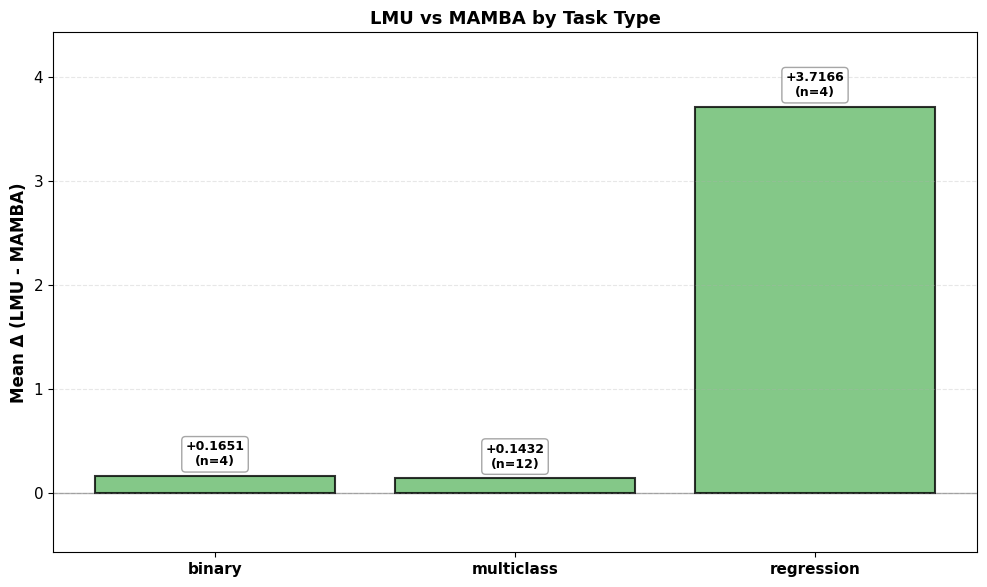

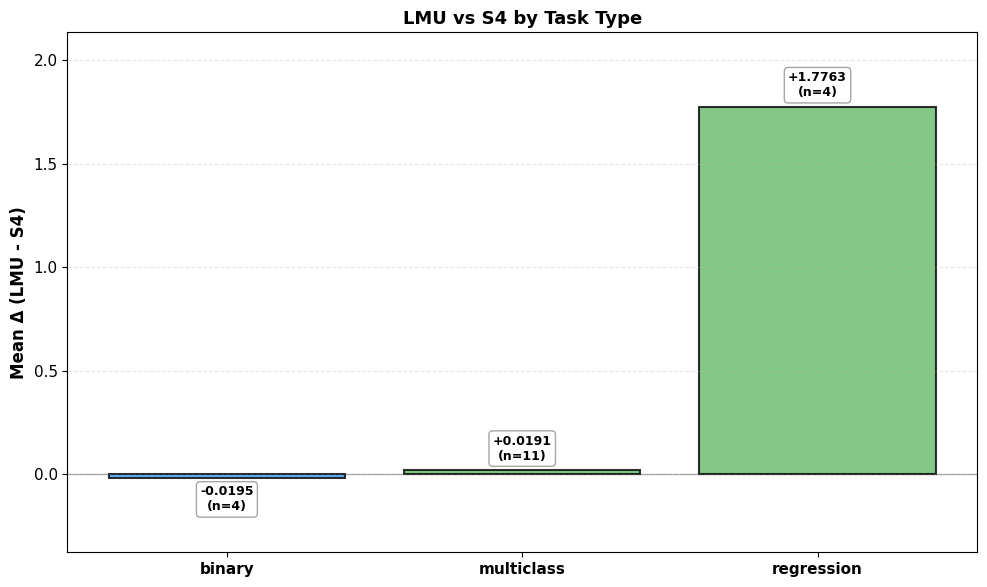

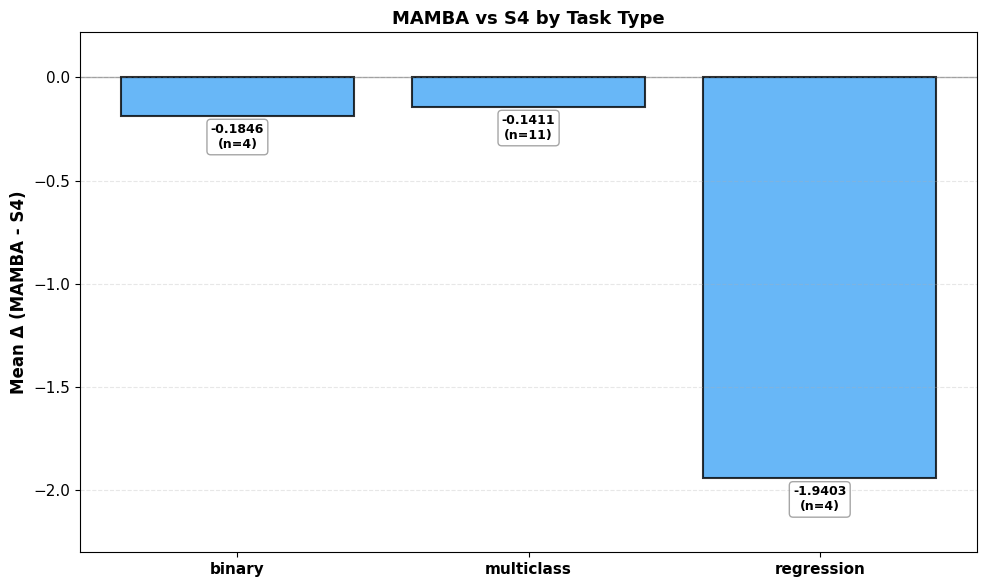


✓ Saved grouped analysis charts for all comparisons


In [5]:
def add_seq_len_bucket(df: pd.DataFrame) -> pd.DataFrame:
    """Add sequence length bucket column."""
    df = df.copy()
    def categorize(seq_len):
        if pd.isna(seq_len):
            return 'unknown'
        elif seq_len < 200:
            return 'short'
        elif seq_len < 1000:
            return 'medium'
        elif seq_len < 5000:
            return 'long'
        else:
            return 'very_long'
    df['seq_len_bucket'] = df['seq_len'].apply(categorize)
    return df

comparison_df_enhanced = add_seq_len_bucket(comparison_df)

# Aggregate by comparison type
print("\nBy Comparison Type:")
print("-" * 60)
for comp_pair in comparison_df_enhanced['comparison'].unique():
    if comp_pair == 'best_model':
        continue
    subset = comparison_df_enhanced[comparison_df_enhanced['comparison'] == comp_pair]
    mean_delta = subset['delta'].mean()
    wins = (subset['delta'] > 0).sum()
    total = len(subset)
    model1, model2 = comp_pair.split('_vs_')
    print(f"{model1.upper():5s} vs {model2.upper():5s}: Δ={mean_delta:+.4f} ({model1.upper()} wins {wins}/{total}, {wins/total*100:.1f}%)")

# Aggregate by task type for each comparison
print("\nBy Task Type (for each comparison):")
print("-" * 60)
for comp_pair in sorted(comparison_df_enhanced['comparison'].unique()):
    if comp_pair == 'best_model':
        continue
    print(f"\n{comp_pair.upper().replace('_', ' ')}:")
    subset = comparison_df_enhanced[comparison_df_enhanced['comparison'] == comp_pair]
    for task_type in subset['task_type'].unique():
        task_subset = subset[subset['task_type'] == task_type]
        mean_delta = task_subset['delta'].mean()
        wins = (task_subset['delta'] > 0).sum()
        total = len(task_subset)
        print(f"  {task_type:15s}: Δ={mean_delta:+.4f} (wins {wins}/{total})")

# Create bar charts for each pairwise comparison
for comp_pair in sorted(comparison_df_enhanced['comparison'].unique()):
    if comp_pair == 'best_model':
        continue

    subset = comparison_df_enhanced[comparison_df_enhanced['comparison'] == comp_pair]
    model1, model2 = comp_pair.split('_vs_')

    # By task type
    task_stats = subset.groupby('task_type')['delta'].agg(['mean', 'count'])
    if len(task_stats) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['#66BB6A' if m > 0 else '#42A5F5' for m in task_stats['mean']]
        bars = ax.bar(range(len(task_stats)), task_stats['mean'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        ax.axhline(0, color='black', linewidth=1, alpha=0.3)

        min_val = task_stats['mean'].min()
        max_val = task_stats['mean'].max()
        data_range = max_val - min_val

        if data_range > 0:
            y_padding = data_range * 0.2
            ax.set_ylim(min_val - y_padding, max_val + y_padding)

        ax.set_xticks(range(len(task_stats)))
        ax.set_xticklabels(task_stats.index, fontweight='bold', rotation=0)
        ax.set_ylabel(f'Mean Δ ({model1.upper()} - {model2.upper()})', fontweight='bold', fontsize=12)
        ax.set_title(f'{model1.upper()} vs {model2.upper()} by Task Type', fontweight='bold', fontsize=13)
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')

        for i, (bar, val, cnt) in enumerate(zip(bars, task_stats['mean'], task_stats['count'])):
            height = bar.get_height()
            if height > 0:
                y_pos = height
                va = 'bottom'
                offset = 0.02 * (max_val - min_val) if data_range > 0 else 0.01
            else:
                y_pos = height
                va = 'top'
                offset = -0.02 * (max_val - min_val) if data_range > 0 else -0.01

            ax.text(bar.get_x() + bar.get_width()/2, y_pos + offset,
                    f'{val:+.4f}\n(n={int(cnt)})',
                    ha='center', va=va, fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.7))

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"grouped_task_type_{comp_pair}.png", dpi=300, bbox_inches='tight')
        plt.show()

print(f"\n✓ Saved grouped analysis charts for all comparisons")


## Visualization: Heatmaps

Generate heatmaps for each pairwise comparison.


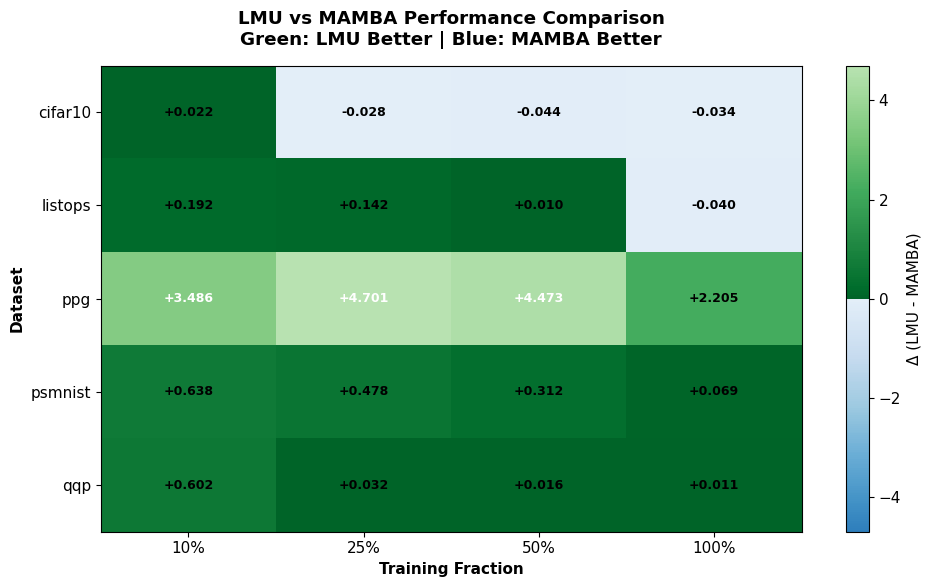

✓ Saved heatmap for lmu_vs_mamba to research_outputs/v2/figures/delta_heatmap_lmu_vs_mamba.png


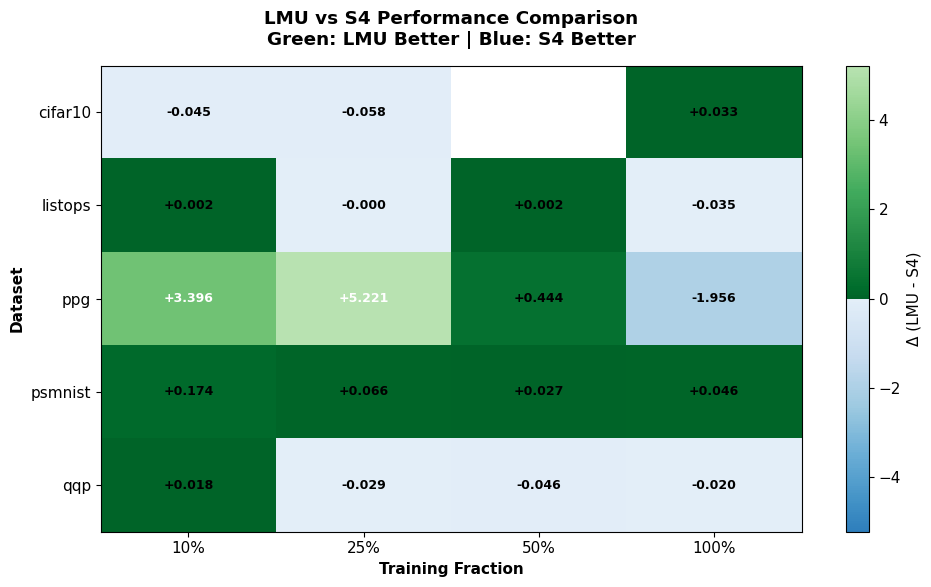

✓ Saved heatmap for lmu_vs_s4 to research_outputs/v2/figures/delta_heatmap_lmu_vs_s4.png


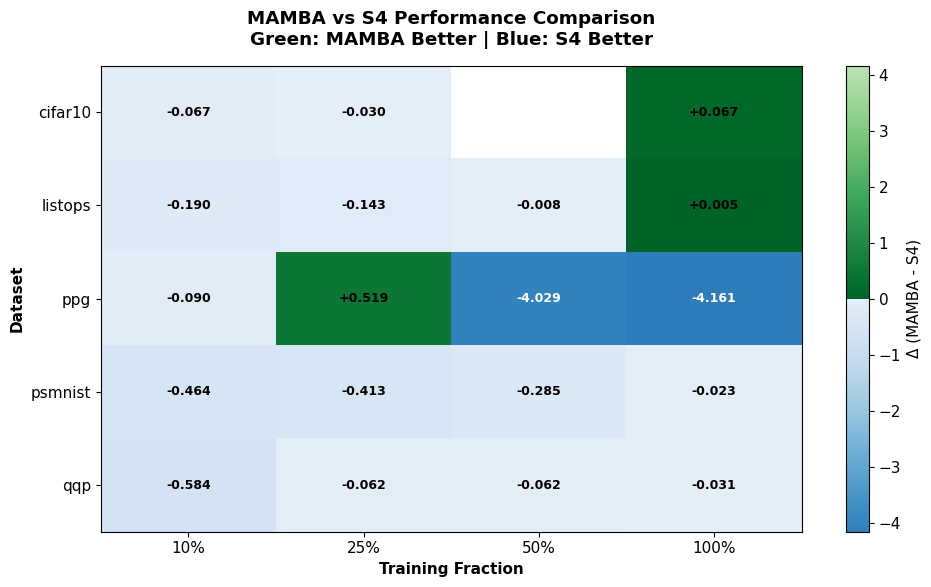

✓ Saved heatmap for mamba_vs_s4 to research_outputs/v2/figures/delta_heatmap_mamba_vs_s4.png


In [6]:
# Create heatmaps for each pairwise comparison
for comp_pair in sorted(comparison_df['comparison'].unique()):
    if comp_pair == 'best_model':
        continue

    model1, model2 = comp_pair.split('_vs_')
    subset = comparison_df[comparison_df['comparison'] == comp_pair]

    # Create pivot table
    pivot = subset.pivot(index='dataset', columns='fraction', values='delta')
    pivot = pivot[sorted(pivot.columns)]

    if len(pivot) == 0:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    vmax = np.nanmax(np.abs(pivot.values))
    colors_blue = plt.cm.Blues_r(np.linspace(0.3, 0.9, 128))
    colors_green = plt.cm.Greens(np.linspace(0.9, 0.3, 128))
    cmap = mcolors.LinearSegmentedColormap.from_list('diverging', np.vstack((colors_blue, colors_green)))

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

    # Labels
    fractions = [f"{f*100:.0f}%" for f in pivot.columns]
    ax.set_xticks(range(len(fractions)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(fractions)
    ax.set_yticklabels(pivot.index)

    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:+.3f}', ha='center', va='center', color=color, fontsize=9, fontweight='bold')

    plt.colorbar(im, ax=ax, label=f'Δ ({model1.upper()} - {model2.upper()})')
    ax.set_xlabel('Training Fraction', fontweight='bold')
    ax.set_ylabel('Dataset', fontweight='bold')
    ax.set_title(f'{model1.upper()} vs {model2.upper()} Performance Comparison\nGreen: {model1.upper()} Better | Blue: {model2.upper()} Better',
                 fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"delta_heatmap_{comp_pair}.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Saved heatmap for {comp_pair} to {FIGURES_DIR}/delta_heatmap_{comp_pair}.png")

if len(comparison_df[comparison_df['comparison'] != 'best_model']) == 0:
    print("\n  Skipping heatmaps - no comparison data available")


## Per-Dataset Plots


In [7]:
# Define colors and markers for each model
MODEL_STYLES = {
    'lmu': {'color': '#2E7D32', 'marker': 'o', 'label': 'LMU'},
    's4': {'color': '#1565C0', 'marker': 's', 'label': 'S4'},
    'mamba': {'color': '#D32F2F', 'marker': '^', 'label': 'Mamba'}
}

plot_datasets = []
for dataset in DATASETS:
    if DATASET_META[dataset].get("subdatasets"):
        for subdataset in DATASET_META[dataset]["subdatasets"]:
            plot_datasets.append((dataset, subdataset, f"{dataset}_{subdataset}"))
    else:
        plot_datasets.append((dataset, None, dataset))

for dataset, subdataset, display_name in plot_datasets:
    if subdataset:
        subset = results_df[(results_df['dataset'] == dataset) & (results_df['subdataset'] == subdataset)]
    else:
        subset = results_df[(results_df['dataset'] == dataset) & (results_df['subdataset'].isna())]

    if len(subset) == 0:
        continue

    fig, ax = plt.subplots(figsize=(8, 5))

    for model in MODELS:
        data = subset[subset['model'] == model].sort_values('fraction')
        if len(data) == 0:
            continue

        style = MODEL_STYLES.get(model, {'color': 'gray', 'marker': 'x', 'label': model.upper()})
        ax.plot(data['fraction'] * 100, data['primary_metric_value'],
                marker=style['marker'], label=style['label'],
                color=style['color'], linewidth=2, markersize=8)

    metric = DATASET_META[dataset]['primary_metric']
    direction = "↑" if DATASET_META[dataset]['higher_is_better'] else "↓"

    ax.set_xlabel('Training Fraction (%)', fontweight='bold')
    ax.set_ylabel(metric.upper(), fontweight='bold')
    ax.set_title(f'{display_name.upper()}: {metric} {direction}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{display_name}_comparison.png", dpi=300, bbox_inches='tight')
    plt.close()

print(f"\n✓ Saved {len(plot_datasets)} comparison plots")



✓ Saved 5 comparison plots


## Summary


In [8]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nResults: {len(results_df)} experiments loaded")
print(f"Datasets: {len(results_df['dataset'].unique())}")
print(f"Models: {', '.join(MODELS)}")
print(f"Figures: {len(list(FIGURES_DIR.glob('*.png')))} saved to {FIGURES_DIR}")

# Overall win rates for all pairwise comparisons
if len(comparison_df[comparison_df['comparison'] != 'best_model']) > 0:
    print(f"\nPairwise Win Rates:")
    for comp_pair in sorted(comparison_df['comparison'].unique()):
        if comp_pair == 'best_model':
            continue
        subset = comparison_df[comparison_df['comparison'] == comp_pair]
        model1, model2 = comp_pair.split('_vs_')
        wins = (subset['delta'] > 0).sum()
        total = len(subset)
        if total > 0:
            print(f"  {model1.upper():6s} vs {model2.upper():6s}: {model1.upper()} wins {wins}/{total} ({wins/total*100:.1f}%)")

# Best model frequency
best_models = comparison_df[comparison_df['comparison'] == 'best_model']
if len(best_models) > 0:
    print(f"\nBest Model Frequency:")
    for model in MODELS:
        count = (best_models['model1'] == model).sum()
        total = len(best_models)
        print(f"  {model.upper():6s}: {count}/{total} ({count/total*100:.1f}%)")

print("\n" + "="*60)



ANALYSIS COMPLETE

Results: 59 experiments loaded
Datasets: 5
Models: lmu, s4, mamba
Figures: 13 saved to research_outputs/v2/figures

Pairwise Win Rates:
  LMU    vs MAMBA : LMU wins 16/20 (80.0%)
  LMU    vs S4    : LMU wins 11/19 (57.9%)
  MAMBA  vs S4    : MAMBA wins 3/19 (15.8%)

Best Model Frequency:
  LMU   : 10/20 (50.0%)
  S4    : 7/20 (35.0%)
  MAMBA : 3/20 (15.0%)



## Export Results


In [9]:
from datetime import datetime

# Create output directory
OUTPUT_DIR = Path("./research_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("EXPORTING RESULTS")
print("="*60)

# 1. Save parsed results DataFrame to CSV
if len(results_df) > 0:
    csv_path = OUTPUT_DIR / "parsed_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Saved parsed results to: {csv_path}")
    print(f"  {len(results_df)} rows × {len(results_df.columns)} columns")

# 2. Save comparison DataFrame to CSV (all pairwise comparisons)
if len(comparison_df) > 0:
    comparison_csv_path = OUTPUT_DIR / "comparison_results.csv"
    comparison_df.to_csv(comparison_csv_path, index=False)
    print(f"\n✓ Saved comparison results to: {comparison_csv_path}")
    print(f"  {len(comparison_df)} rows × {len(comparison_df.columns)} columns")

# 3. Generate Markdown Summary Report
if len(comparison_df) > 0:
    summary_path = OUTPUT_DIR / "summary.md"

    with open(summary_path, 'w') as f:
        # Header
        f.write(f"# Comparative Analysis: {' vs '.join([m.upper() for m in MODELS])} - Summary Report\n\n")
        f.write(f"**Generated**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write("---\n\n")

        # Dataset Coverage Table
        f.write("## Dataset Coverage\n\n")

        # Dynamic header based on MODELS
        header_cols = " | ".join([m.upper() for m in MODELS])
        f.write(f"| Dataset | {header_cols} | Total | Fractions |\n")
        f.write(f"|---------|{'-|' * len(MODELS)}-------|----------|----------|\n")

        for dataset in sorted(results_df['dataset'].unique()):
            subset = results_df[results_df['dataset'] == dataset]

            # Count for each model
            model_counts = []
            for model in MODELS:
                count = len(subset[subset['model'] == model])
                model_counts.append(str(count))

            total_count = len(subset)
            fractions = sorted(subset['fraction'].unique())
            frac_str = ", ".join([f"{f*100:.0f}%" for f in fractions])

            counts_str = " | ".join(model_counts)
            f.write(f"| {dataset} | {counts_str} | {total_count} | {frac_str} |\n")

        f.write(f"\n**Total**: {len(results_df)} experiments across {len(results_df['dataset'].unique())} datasets\n\n")

        # Pairwise Win Rates
        f.write("---\n\n")
        f.write("## Pairwise Win Rates\n\n")
        f.write("| Comparison | First Model Wins | Total | Win Rate |\n")
        f.write("|------------|------------------|-------|----------|\n")

        for comp_pair in sorted(comparison_df['comparison'].unique()):
            if comp_pair == 'best_model':
                continue
            subset = comparison_df[comparison_df['comparison'] == comp_pair]
            wins = (subset['delta'] > 0).sum()
            total = len(subset)
            if total > 0:
                model1, model2 = comp_pair.split('_vs_')
                f.write(f"| {model1.upper()} vs {model2.upper()} | {wins} | {total} | {wins/total*100:.1f}% |\n")

        # Best Model Frequency
        best_models = comparison_df[comparison_df['comparison'] == 'best_model']
        if len(best_models) > 0:
            f.write("\n## Best Model Frequency\n\n")
            f.write("| Model | Times Best | Total | Frequency |\n")
            f.write("|-------|------------|-------|----------|\n")
            for model in MODELS:
                count = (best_models['model1'] == model).sum()
                total_best = len(best_models)
                f.write(f"| {model.upper()} | {count} | {total_best} | {count/total_best*100:.1f}% |\n")

        # Top wins for each pairwise comparison
        for comp_pair in sorted(comparison_df['comparison'].unique()):
            if comp_pair == 'best_model':
                continue

            model1, model2 = comp_pair.split('_vs_')
            subset = comparison_df[comparison_df['comparison'] == comp_pair]

            # Top-5 wins for model1
            f.write(f"\n---\n\n")
            f.write(f"## Top-5 {model1.upper()} Wins over {model2.upper()} (by absolute Δ)\n\n")
            f.write("| Rank | Dataset | Fraction | Δ | Value (Model1) | Value (Model2) |\n")
            f.write("|------|---------|----------|---|----------------|----------------|\n")

            wins_df = subset[subset['delta'] > 0].copy()
            wins_df['abs_delta'] = wins_df['delta'].abs()
            top_wins = wins_df.nlargest(5, 'abs_delta')

            for idx, (rank, row) in enumerate(top_wins.iterrows(), 1):
                f.write(f"| {rank} | {row['dataset']} | {row['fraction']*100:.0f}% | "
                       f"+{row['delta']:.4f} | {row['model1_value']:.4f} | {row['model2_value']:.4f} |\n")

            if len(top_wins) == 0:
                f.write(f"| - | No {model1.upper()} wins | - | - | - | - |\n")

        # Per-Task-Type Analysis
        if 'task_type' in comparison_df.columns:
            f.write("\n---\n\n")
            f.write("## Performance by Task Type\n\n")

            for comp_pair in sorted(comparison_df['comparison'].unique()):
                if comp_pair == 'best_model':
                    continue

                model1, model2 = comp_pair.split('_vs_')
                subset = comparison_df[comparison_df['comparison'] == comp_pair]

                f.write(f"\n### {model1.upper()} vs {model2.upper()}\n\n")
                f.write("| Task Type | Mean Δ @ 10% | Mean Δ @ 100% | Change | Count |\n")
                f.write("|-----------|--------------|---------------|--------|-------|\n")

                for task_type in sorted(subset['task_type'].unique()):
                    task_subset = subset[subset['task_type'] == task_type]

                    # At 10%
                    at_10 = task_subset[task_subset['fraction'] == 0.1]
                    mean_10 = at_10['delta'].mean() if len(at_10) > 0 else float('nan')

                    # At 100%
                    at_100 = task_subset[task_subset['fraction'] == 1.0]
                    mean_100 = at_100['delta'].mean() if len(at_100) > 0 else float('nan')

                    # Change
                    if pd.notna(mean_10) and pd.notna(mean_100):
                        change = mean_100 - mean_10
                        change_str = f"{change:+.4f}"
                    else:
                        change_str = "N/A"

                    mean_10_str = f"{mean_10:+.4f}" if pd.notna(mean_10) else "N/A"
                    mean_100_str = f"{mean_100:+.4f}" if pd.notna(mean_100) else "N/A"

                    f.write(f"| {task_type} | {mean_10_str} | {mean_100_str} | {change_str} | {len(task_subset)} |\n")

        # Overall Statistics
        f.write("\n---\n\n")
        f.write("## Overall Statistics\n\n")
        f.write(f"- **Total Experiments**: {len(results_df)}\n")
        f.write(f"- **Total Pairwise Comparisons**: {len(comparison_df[comparison_df['comparison'] != 'best_model'])}\n")
        f.write(f"- **Datasets**: {len(results_df['dataset'].unique())}\n")
        f.write(f"- **Models**: {', '.join(MODELS)}\n")

        # Footer
        f.write("\n---\n\n")
        f.write("*Δ > 0 indicates first model performs better; Δ < 0 indicates second model performs better*\n")

    print(f"\n✓ Saved markdown summary to: {summary_path}")

print("\n" + "="*60)
print("EXPORT COMPLETE")
print("="*60)


EXPORTING RESULTS

✓ Saved parsed results to: research_outputs/parsed_results.csv
  59 rows × 7 columns

✓ Saved comparison results to: research_outputs/comparison_results.csv
  78 rows × 12 columns

✓ Saved markdown summary to: research_outputs/summary.md

EXPORT COMPLETE
